# 20. Интерпретация модели с SHAP: от общей картины до одной квартиры

| | |
|---|---|
| **Уровень** | 3 из 4 — средние данные: полный цикл и типовые случаи (`3_medium`) |
| **Скрипт-источник** | [`20_shap_interpretation.py`](../20_shap_interpretation.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 4 с |

**Цель.** Объяснить модель бустинга стандартными инструментами библиотеки shap.

### Чему вы научитесь

- `shap.TreeExplainer` и аддитивность вкладов
- Сводный график (beeswarm)
- График зависимости
- Значения взаимодействий SHAP
- «водопад» для одного объекта
- Как проверить, что модель нашла истинную структуру

### Данные

`_data.make_houses` — 20 000 квартир, цель — `log(цены)`. Истинная зависимость известна: цена ~ площадь, район, расстояние, ремонт; первый и последний этажи дешевле; новые дома дороже только близко к центру.

### План

1. **Этап 1.** Данные и модель (категории — числовыми кодами: так shap работает с XGBoost 3.x без оговорок)
2. **Этап 2.** TreeExplainer: база + сумма вкладов = прогноз
3. **Этап 3.** Средний |SHAP| и сводный график
4. **Этап 4.** Проверяем, нашла ли модель заложенные эффекты
5. **Этап 5.** Объяснение одной квартиры (водопад)

> Ноутбук собран из `examples/3_medium/20_shap_interpretation.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_houses

ex = Example(EXAMPLES / "3_medium/20_shap_interpretation.py", title="20. Интерпретация с SHAP",
             goal="объяснить модель целиком и отдельный прогноз и сверить с истинной структурой")

import matplotlib.pyplot as plt
import numpy as np
import shap
import xgboost as xgb

## Этап 1. Данные и модель (категории — числовыми кодами: так shap работает с XGBoost 3.x без оговорок)

In [2]:
X, price = make_houses(ex.size(20_000, 4000), seed=20)
y = np.log(price)
Xn = X.assign(район=X["район"].cat.codes, ремонт=X["ремонт"].cat.codes)
ex.describe(Xn, y, target="log(цена)", source="examples/_data.py → make_houses")
model = xgb.XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8).fit(Xn, y)

   Источник: examples/_data.py → make_houses
   Объектов: 20 000   признаков: 10   память: 1.26 МБ
   Типы признаков: int64 × 5, float64 × 3, int8 × 2
   Пропуски: кухня 5.4%
   Цель «log(цена)»: среднее 2.064, σ 0.476, мин -0.071, макс 3.642
   Первые строки:


,площадь,комнаты,этаж,этажность,год,до_центра_км,район,парковка,ремонт,кухня,[log(цена)]
0,49.9,2,24,25,2025,6.44,1,1,3,8.8,2.363021
1,42.9,2,5,5,2001,11.64,3,0,3,8.3,1.374222
2,46.5,2,4,5,2002,12.07,0,0,3,8.3,1.717575


## Этап 2. TreeExplainer: база + сумма вкладов = прогноз

In [3]:
sample = Xn.iloc[:2000]
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(sample)
base = float(np.ravel(explainer.expected_value)[0])
err = np.abs(base + sv.sum(1) - model.predict(sample, output_margin=True)).max()
print(f"   база φ₀ = {base:.4f}; наибольшая ошибка аддитивности {err:.1e}")
assert err < 1e-3

   база φ₀ = 2.0634; наибольшая ошибка аддитивности 4.5e-06


## Этап 3. Средний |SHAP| и сводный график

   площадь      0.3000
   район        0.1397
   до_центра_км 0.1258
   ремонт       0.0720
   год          0.0370
   этаж         0.0226
   парковка     0.0198
   этажность    0.0135
   кухня        0.0048
   комнаты      0.0021


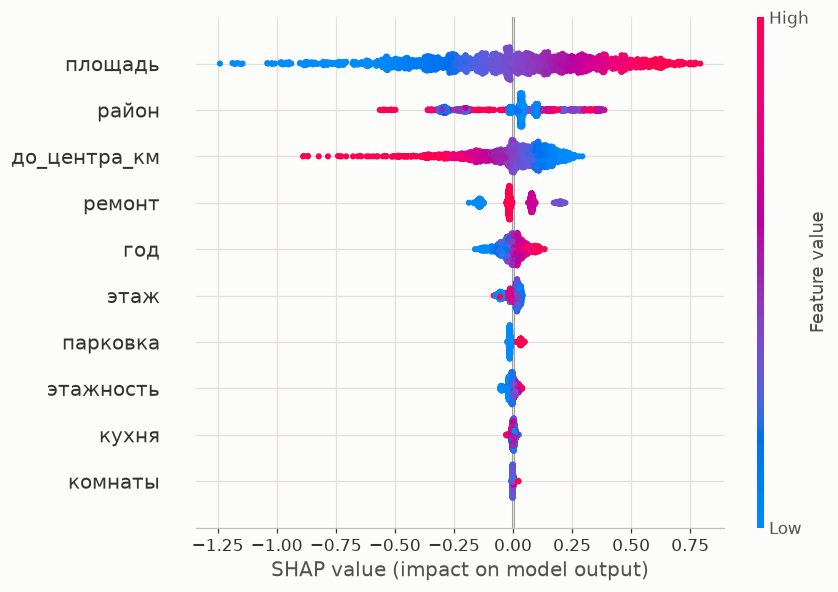

In [4]:
imp = np.abs(sv).mean(0)
for j in np.argsort(-imp):
    print(f"   {Xn.columns[j]:12s} {imp[j]:.4f}")
shap.summary_plot(sv, sample, show=False)
ex.finish(plt.gcf(), "20_shap_summary")

## Этап 4. Проверяем, нашла ли модель заложенные эффекты

   вклад этажа: крайние этажи -0.0389, остальные +0.0144  (заложено: крайние дешевле на 8% → log ≈ −0.083)


> ▸ **Вывод.** Модель нашла эффект, но смягчила его: разница крайних и остальных этажей около −0.05 при истинной −0.083. Часть эффекта SHAP относит к «этажности», с которой этаж связан. Значения Шепли описывают модель, а не мир.

   самое сильное взаимодействие по SHAP: год × до_центра_км
   взаимодействие «год × до центра» (заложено: новизна важна только близко к центру): 0.0141


> ▸ **Вывод.** Самое сильное взаимодействие — именно заложенное в данные: «год постройки × расстояние до центра».

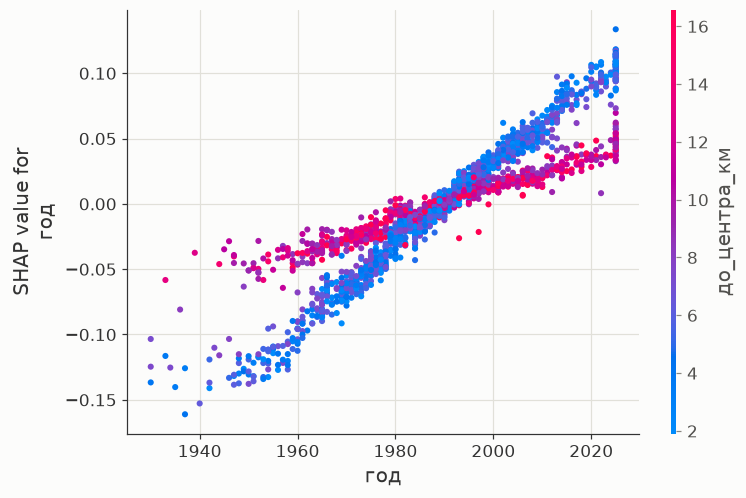

In [5]:
floor_first = (sample["этаж"] == 1) | (sample["этаж"] == sample["этажность"])
j = list(Xn.columns).index("этаж")
print(f"   вклад этажа: крайние этажи {sv[floor_first.to_numpy(), j].mean():+.4f}, остальные {sv[~floor_first.to_numpy(), j].mean():+.4f}"
      f"  (заложено: крайние дешевле на 8% → log ≈ −0.083)")
ex.note("""Модель нашла эффект, но смягчила его: разница крайних и остальных этажей около −0.05 при истинной −0.083.
Часть эффекта SHAP относит к «этажности», с которой этаж связан. Значения Шепли описывают модель, а не мир.""")
iv = explainer.shap_interaction_values(sample.iloc[:500])
inter = np.abs(iv).mean(0)
np.fill_diagonal(inter, 0)
a, b = np.unravel_index(np.argmax(inter), inter.shape)
print(f"   самое сильное взаимодействие по SHAP: {Xn.columns[a]} × {Xn.columns[b]}")
assert {Xn.columns[a], Xn.columns[b]} == {"год", "до_центра_км"}
jy, jd = list(Xn.columns).index("год"), list(Xn.columns).index("до_центра_км")
print(f"   взаимодействие «год × до центра» (заложено: новизна важна только близко к центру): {inter[jy, jd]:.4f}")
ex.note("Самое сильное взаимодействие — именно заложенное в данные: «год постройки × расстояние до центра».")
shap.dependence_plot("год", sv, sample, interaction_index="до_центра_км", show=False)
ex.finish(plt.gcf(), "20_shap_dependence_year")

## Этап 5. Объяснение одной квартиры (водопад)

   квартира: площадь=49.9, комнаты=2, этаж=24, этажность=25, год=2025, до_центра_км=6.44, район=район_01
   прогноз 10.45 млн, факт 10.62 млн


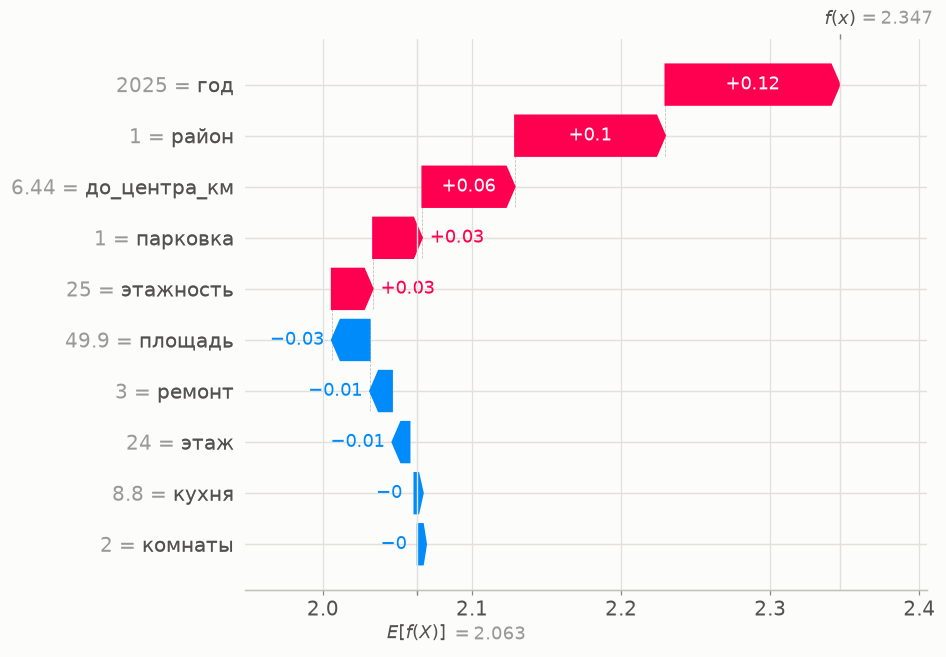

Готово за 2.9 с


In [6]:
i = 0
print("   квартира: " + ", ".join(f"{c}={X.iloc[i][c]}" for c in X.columns[:7]))
print(f"   прогноз {np.exp(model.predict(Xn.iloc[:1])[0]):.2f} млн, факт {price[i]:.2f} млн")
exp1 = shap.Explanation(values=sv[i], base_values=base, data=sample.iloc[i].to_numpy(), feature_names=list(Xn.columns))
shap.plots.waterfall(exp1, show=False)
ex.finish(plt.gcf(), "20_shap_waterfall")
ex.done()

## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Постройте графики зависимости для площади и района.
2. Объясните водопадом самую дорогую и самую дешёвую квартиру выборки.
3. Сравните порядок признаков по среднему |SHAP| и по важности gain XGBoost.

## Что дальше

- **Теория в курсе:** [12 «Интерпретация»](../../../lessons/lesson_12/README.md), [12.2 «SHAP»](../../../lessons/lesson_12_2/README.md).
- **Предыдущий пример:** [19. Настройка гиперпараметров: кросс-валидация LightGBM и поиск Optuna](19_cv_and_optuna.ipynb)
- **Следующий пример:** [21. Картинки рукописных цифр (1797 × 64 пикселя): где бустинг — не лучший выбор](21_digits_images.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)